# Actividad práctica: Segmentación de clientes mediante clustering

En esta actividad se trabajará con un conjunto de datos de clientes con el objetivo de identificar segmentos con características similares mediante técnicas de agrupamiento.

La segmentación se construirá utilizando **edad** e **ingreso anual**, dos variables cuantitativas que permiten trabajar directamente con distancias y visualizar los resultados en dos dimensiones. Las demás variables del conjunto de datos se utilizarán posteriormente para **caracterizar e interpretar** los grupos encontrados.

Se aplicarán dos métodos vistos en la unidad:

- K-Means.
- Agrupamiento jerárquico aglomerativo.

Para evaluar las soluciones se utilizarán la inercia o WCSS, el método del codo y el índice de silueta.

> ## **Se espera como entrega**

> Esta Notebook resuelta con el agregado del grupo al final del nombre
> Ejemplo Actividad_Clustering_Segmentacion_clientes_grupo_X.ipynb (reemplazar X por el número del grupo)


## Descripción del conjunto de datos

El siguiente conjunto de datos consiste en información sobre el comportamiento de compra de 2,000 individuos de una determinada área al entrar en una tienda física de bienes de consumo rápido. Todos los datos se han recopilado a través de las tarjetas que utilizan al momento de pagar. Los datos han sido preprocesados y no hay valores faltantes. Además, el volumen del conjunto de datos se ha limitado y anonimizado para proteger la privacidad de los clientes.

Columnas del conjunto de datos:

- **Sex**: género.  
  0: masculino,  
  1: femenino.
- **Marital status**: estado civil de un cliente.  
  0: soltero,  
  1: no soltero (divorciado/separado/casado/viudo).
- **Age**: edad del cliente en años. Valor mínimo: 18, valor máximo: 78.
- **Education**: nivel educativo del cliente.  
  0: otro/desconocido,  
  1: escuela secundaria,  
  2: universidad,  
  3: posgrado.
- **Income**: ingreso anual autoreportado en dólares estadounidenses del cliente. Valor mínimo: 35,832, valor máximo: 309,364.
- **Occupation**: categoría de la ocupación del cliente.  
  0: desempleado/no calificado,  
  1: empleado calificado/funcionario,  
  2: administración/autónomo/empleado altamente calificado/oficial.
- **Settlement size**: tamaño de la ciudad donde vive el cliente.  
  0: ciudad pequeña,  
  1: ciudad mediana,  
  2: gran ciudad.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42

### 1. Exploración inicial

Antes de aplicar un algoritmo de clustering, analice la estructura del conjunto de datos `customer_data.csv` y analice las variables `Age` e `Income` mediante estadísticos descriptivos. Represente gráficamente la relación entre edad e ingreso.

¿Se observan grupos claramente separados a simple vista en el plano edad-ingreso?

In [2]:
datos = pd.read_csv("customer_data.csv")
datos.head()

#Para ver los datos descriptivos de las variables seleccionada
datos[["Age", "Income"]].describe()

,Age,Income
count,2000.000000,2000.000000
mean,35.909000,120954.419000
std,11.719402,38108.824679
min,18.000000,35832.000000
25%,27.000000,97663.250000
50%,33.000000,115548.500000
75%,42.000000,138072.250000
max,76.000000,309364.000000


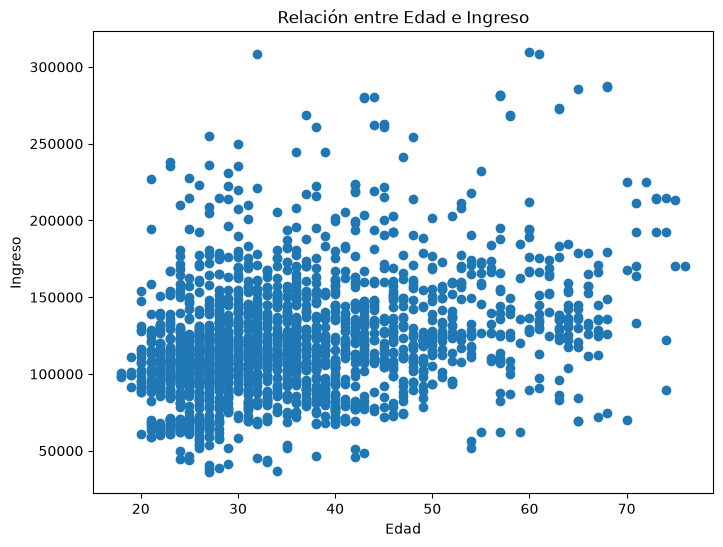

In [3]:
#Grafica de los datos
plt.figure(figsize=(8, 6))

plt.scatter(datos["Age"], datos["Income"])

plt.xlabel("Edad")
plt.ylabel("Ingreso")
plt.title("Relación entre Edad e Ingreso")

plt.show()

No se observan grupos claramente separados en el plano edad-ingreso, se ve una gran concentración de clientes con un ingreso de entre los 60000 y 150000 en un rango de edad entre 20 y 50 años. Además, se observan algunos valores alejados que podrian corresponder a valores atípicos.  

### 2. Selección de características y escalado

Para construir los clusters se utilizarán únicamente:

$$
X = [\text{Age},\text{Income}]
$$

Las demás variables se reservarán para describir los segmentos una vez obtenidos.

In [4]:
#Selección de variables para el clustering
X = datos[["Age", "Income"]]
X.head()
#Escalado de las variables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
#Comprobamos resultados
print(X_scaled)

[[ 2.65361447  0.09752361]
 [-1.18713209  0.78265438]
 [ 1.11731585 -0.83320224]
 ...
 [-0.41898277 -0.90695688]
 [-1.01643224 -0.60332923]
 [-0.93108232 -1.3789866 ]]


### 3. Selección del número de clusters con K-Means

No se conoce de antemano cuántos grupos existen en los datos.

1. Ajuste K-Means para valores de $K$ entre 1 y 10.
2. Registre la inercia o WCSS para cada valor de $K$.
3. Para $K \geq 2$, calcule además el coeficiente de silueta promedio.
4. Represente:
   - WCSS en función de $K$.
   - coeficiente de silueta promedio en función de $K$.
5. Identifique los valores de $K$ que considera más razonables y justifique.

In [5]:
# Ajuste de K-Means para distintos valores de K
k_values = range(1, 11)
inertias = []
silhouette_scores = []

for k in k_values:
    modelo = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    etiquetas = modelo.fit_predict(X_scaled)
    inertias.append(modelo.inertia_)

    if k >= 2:
        silhouette_scores.append(
            silhouette_score(
                X_scaled,
                etiquetas,
                sample_size=min(1000, len(X_scaled)),
                random_state=RANDOM_STATE
            )
        )
    else:
        silhouette_scores.append(np.nan)

resultados_kmeans = pd.DataFrame({
    "K": list(k_values),
    "WCSS": inertias,
    "Silueta": silhouette_scores
})

resultados_kmeans

,K,WCSS,Silueta
0,1,4000.000000,NaN
1,2,2260.203698,0.451497
2,3,1647.554007,0.449660
3,4,1281.144689,0.352418
4,5,1024.239358,0.370096
5,6,865.905570,0.356044
6,7,751.305572,0.362291
7,8,665.029482,0.362248
8,9,582.929005,0.365802
9,10,511.234338,0.367869


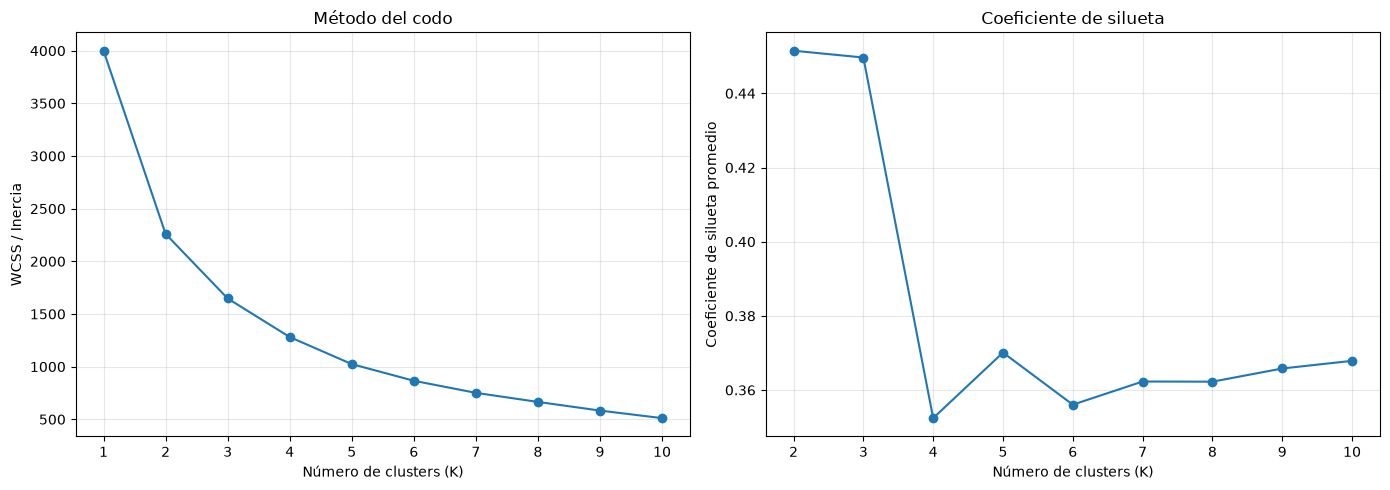

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(resultados_kmeans["K"], resultados_kmeans["WCSS"], marker="o")
axes[0].set_xlabel("Número de clusters (K)")
axes[0].set_ylabel("WCSS / Inercia")
axes[0].set_title("Método del codo")
axes[0].set_xticks(list(k_values))
axes[0].grid(alpha=0.3)

axes[1].plot(resultados_kmeans["K"][1:], resultados_kmeans["Silueta"][1:], marker="o")
axes[1].set_xlabel("Número de clusters (K)")
axes[1].set_ylabel("Coeficiente de silueta promedio")
axes[1].set_title("Coeficiente de silueta")
axes[1].set_xticks(list(k_values)[1:])
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 4. Análisis de los diagramas de silueta

El coeficiente promedio resume el resultado en un único número, pero no permite observar cómo se comportan las observaciones dentro de cada cluster.

Construya diagramas de silueta para $K=2$, $K=3$, $K=4$ y $k=5$.

Interprételo de acuerdo a los criterios vistos en la notebook de práctica.

Utilice esta información para complementar la elección de $K$.

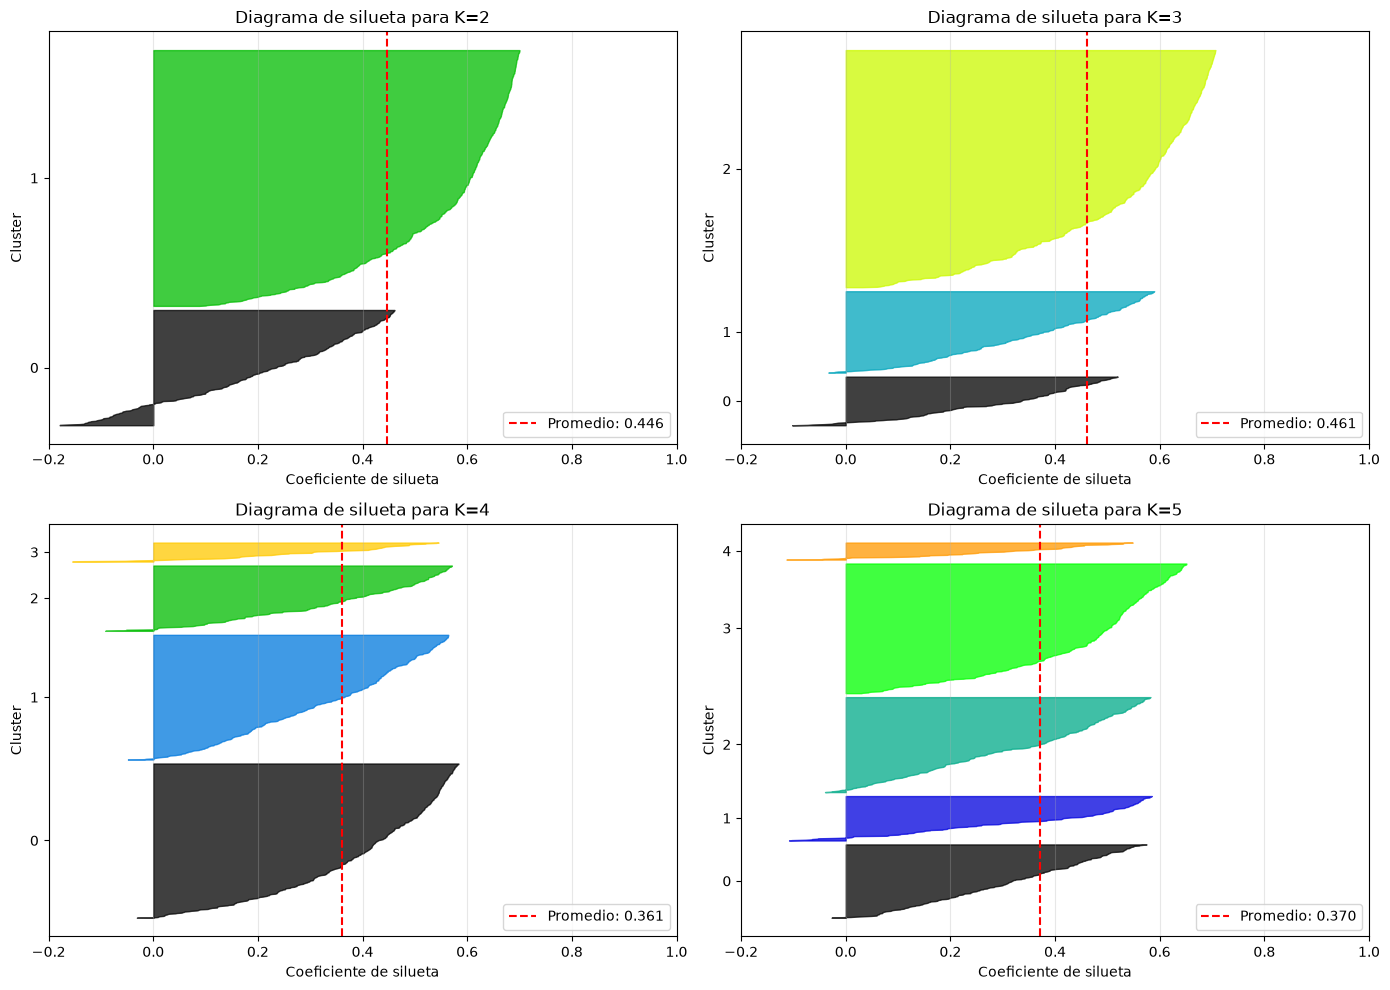

,K,Silueta promedio
0,2,0.446137
1,3,0.461354
2,4,0.361352
3,5,0.370407


In [7]:
from matplotlib.ticker import FixedLocator, FixedFormatter

k_values_silueta = [2, 3, 4, 5]
rng = np.random.default_rng(RANDOM_STATE)
indices_silueta = rng.choice(
    len(X_scaled),
    size=min(1000, len(X_scaled)),
    replace=False
)
X_silueta = X_scaled[indices_silueta]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
resultados_silueta = []

for ax, k in zip(axes.ravel(), k_values_silueta):
    modelo = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    etiquetas = modelo.fit_predict(X_silueta)
    coeficientes = silhouette_samples(X_silueta, etiquetas)
    promedio = coeficientes.mean()
    resultados_silueta.append({"K": k, "Silueta promedio": promedio})

    posicion = 10
    marcas = []
    espacio = 10

    for cluster in range(k):
        valores = np.sort(coeficientes[etiquetas == cluster])
        inicio = posicion
        fin = posicion + len(valores)
        color = plt.cm.nipy_spectral(cluster / k)

        ax.fill_betweenx(
            np.arange(inicio, fin),
            0,
            valores,
            facecolor=color,
            edgecolor=color,
            alpha=0.75
        )
        marcas.append(inicio + len(valores) // 2)
        posicion = fin + espacio

    ax.axvline(promedio, color="red", linestyle="--", label=f"Promedio: {promedio:.3f}")
    ax.set_title(f"Diagrama de silueta para K={k}")
    ax.set_xlabel("Coeficiente de silueta")
    ax.set_xlim(-0.2, 1)
    ax.grid(axis="x", alpha=0.3)
    ax.legend(loc="lower right")
    ax.yaxis.set_major_locator(FixedLocator(marcas))
    ax.yaxis.set_major_formatter(FixedFormatter(range(k)))
    ax.set_ylabel("Cluster")

plt.tight_layout()
plt.show()

resultados_silueta = pd.DataFrame(resultados_silueta)
resultados_silueta

### Interpretación

Los diagramas muestran que las soluciones con $K=2$ y $K=3$ presentan los mejores coeficientes de silueta promedio. En particular, $K=3$ alcanza el promedio más alto en la muestra analizada, aproximadamente $0{,}461$, mientras que $K=2$ obtiene aproximadamente $0{,}446$.

Para $K=4$ y $K=5$ el promedio disminuye y aparecen más observaciones cercanas a cero o con valores negativos. Esto indica que al dividir los clientes en más grupos se pierde parte de la separación entre clusters y algunas asignaciones resultan menos claras.

Por lo tanto, los diagramas respaldan considerar $K=2$ y $K=3$ como las alternativas más razonables. La elección final debe complementarse con el método del codo y con la interpretación de los perfiles de clientes.

### 5. Segmentación final con K-Means

Ajuste un modelo K-Means utilizando el valor de K seleccionado.

1. Obtenga la etiqueta asignada a cada cliente.
2. Represente los clusters utilizando las variables originales `Age` e `Income`.
3. Calcule los centroides y represéntelos en el gráfico.
4. Interprete qué representan los grupos obtenidos.

Recuerde que los números asignados a los clusters son identificadores arbitrarios: `Cluster 0` no implica que ese grupo sea menor o más importante que `Cluster 1`.

In [8]:
K_SELECCIONADO = 3

modelo_kmeans = KMeans(
    n_clusters=K_SELECCIONADO,
    random_state=RANDOM_STATE,
    n_init=10
)

etiquetas_kmeans = modelo_kmeans.fit_predict(X_scaled)
datos_segmentados = datos.copy()
datos_segmentados["Cluster"] = etiquetas_kmeans

centroides_originales = scaler.inverse_transform(modelo_kmeans.cluster_centers_)
centroides = pd.DataFrame(
    centroides_originales,
    columns=["Age", "Income"]
)
centroides.index.name = "Cluster"

print(f"Cantidad de clientes: {len(datos_segmentados)}")
print(f"Cantidad de clusters: {K_SELECCIONADO}")
display(centroides)

Cantidad de clientes: 2000
Cantidad de clusters: 3


,Age,Income
Cluster,,
0,35.893372,175604.582133
1,29.708539,101742.805419
2,53.282759,131152.439080


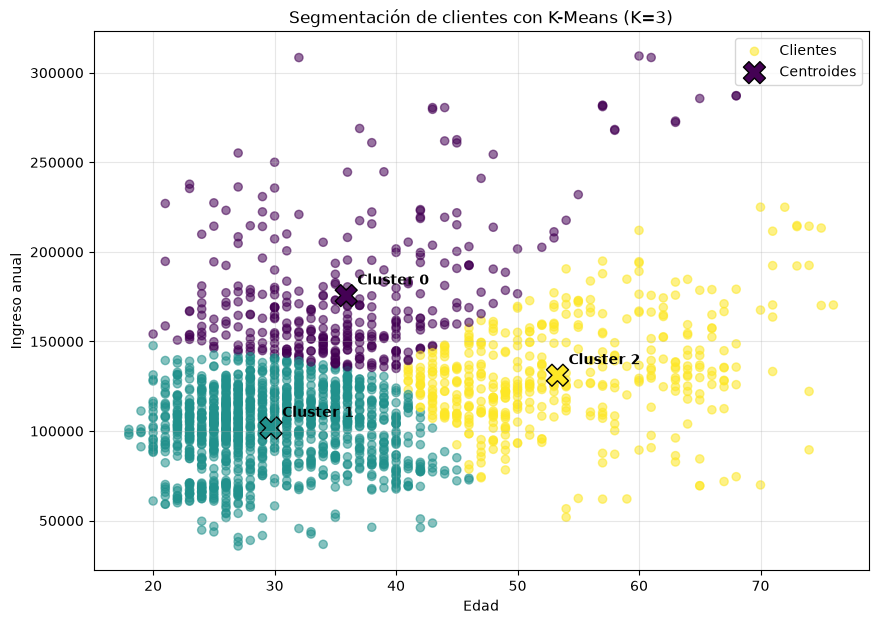

Cantidad de clientes por cluster:


Cluster
0     347
1    1218
2     435
Name: Cantidad, dtype: int64

In [10]:
plt.figure(figsize=(10, 7))

plt.scatter(
    datos_segmentados["Age"],
    datos_segmentados["Income"],
    c=datos_segmentados["Cluster"],
    cmap="viridis",
    alpha=0.55,
    s=35,
    label="Clientes"
)

plt.scatter(
    centroides["Age"],
    centroides["Income"],
    c=centroides.index,
    cmap="viridis",
    marker="X",
    edgecolor="black",
    s=250,
    label="Centroides"
)

for cluster, centroide in centroides.iterrows():
    plt.annotate(
        f"Cluster {cluster}",
        (centroide["Age"], centroide["Income"]),
        xytext=(8, 8),
        textcoords="offset points",
        fontweight="bold"
    )

plt.xlabel("Edad")
plt.ylabel("Ingreso anual")
plt.title(f"Segmentación de clientes con K-Means (K={K_SELECCIONADO})")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

tamanos_clusters = datos_segmentados["Cluster"].value_counts().sort_index()
print("Cantidad de clientes por cluster:")
display(tamanos_clusters.rename("Cantidad"))

Interpretación de la segmentación

La solución elegida utiliza K=3 y asigna los 2.000 clientes de la siguiente manera:

- Cluster 0: 347 clientes, con una edad promedio de aproximadamente 36 años y un ingreso promedio cercano a $175.605. Es el grupo de ingresos más altos.
- Cluster 1: 1.218 clientes, con una edad promedio de aproximadamente 30 años y un ingreso promedio cercano a $101.743. Es el grupo más numeroso y representa clientes jóvenes con ingresos medios.
- Cluster 2: 435 clientes, con una edad promedio de aproximadamente 53 años y un ingreso promedio cercano a $131.152. Representa clientes de mayor edad con ingresos medios-altos.

Los centroides permiten resumir el perfil promedio de cada grupo. Como las etiquetas son arbitrarias, que un grupo se denomine Cluster 0, Cluster 1 o Cluster 2 no implica un orden de importancia.

### 6. Caracterización de los segmentos

Agregue las etiquetas de K-Means al conjunto de datos original y describa cada cluster utilizando las características disponibles.

Para cada grupo analice:

- cantidad de clientes;
- edad media y mediana;
- ingreso medio y mediano;
- distribución por género;
- estado civil;
- nivel educativo;
- ocupación;
- tamaño de la ciudad de residencia.

A partir de estos resultados, elabore una descripción breve de cada segmento. Puede utilizar herramientas de `pandas` para esta tarea.

In [11]:
resumen_numerico = datos_segmentados.groupby("Cluster").agg(
    Clientes=("ID", "count"),
    Edad_media=("Age", "mean"),
    Edad_mediana=("Age", "median"),
    Ingreso_medio=("Income", "mean"),
    Ingreso_mediano=("Income", "median")
).round(2)

resumen_numerico

,Clientes,Edad_media,Edad_mediana,Ingreso_medio,Ingreso_mediano
Cluster,,,,,
0,347,35.89,35.0,175604.58,162827.0
1,1218,29.71,29.0,101742.81,104405.5
2,435,53.28,51.0,131152.44,127825.0


In [12]:
variables_categoricas = [
    "Sex",
    "Marital status",
    "Education",
    "Occupation",
    "Settlement size"
]

for variable in variables_categoricas:
    distribucion = pd.crosstab(
        datos_segmentados["Cluster"],
        datos_segmentados[variable],
        normalize="index"
    ).mul(100).round(1)

    print(f"Distribución porcentual de {variable} por cluster:")
    display(distribucion)

perfiles = datos_segmentados.groupby("Cluster")[variables_categoricas].agg(
    lambda columna: columna.value_counts().index[0]
)

perfiles.columns = [f"{variable} (moda)" for variable in variables_categoricas]
print("Categoría más frecuente de cada variable por cluster:")
display(perfiles)

Distribución porcentual de Sex por cluster:


Sex,0,1
Cluster,,
0,74.6,25.4
1,45.1,54.9
2,63.9,36.1


Distribución porcentual de Marital status por cluster:


Marital status,0,1
Cluster,,
0,60.5,39.5
1,43.3,56.7
2,62.1,37.9


Distribución porcentual de Education por cluster:


...

Occupation,0,1,2
Cluster,,,
0,3.7,44.4,51.9
1,40.1,57.6,2.3
2,30.1,59.3,10.6


Distribución porcentual de Settlement size por cluster:


Settlement size,0,1,2
Cluster,,,
0,12.1,41.2,46.7
1,62.8,21.1,16.1
2,41.8,33.1,25.1


Categoría más frecuente de cada variable por cluster:


,Sex (moda),Marital status (moda),Education (moda),Occupation (moda),Settlement size (moda)
Cluster,,,,,
0,0,0,1,2,2
1,1,1,1,1,0
2,0,0,2,1,0


### Interpretación de los segmentos

- **Cluster 0**: es el grupo de ingresos más altos. Predominan los hombres, el nivel educativo secundario, la ocupación 2 y la residencia en ciudades grandes.
- **Cluster 1**: es el grupo más numeroso y joven. Presenta ingresos medios, leve mayoría de mujeres, mayor proporción de clientes no solteros, educación secundaria, ocupación 1 y residencia en ciudades pequeñas.
- **Cluster 2**: reúne a los clientes de mayor edad. Tiene ingresos medios-altos, predominio masculino, educación universitaria, ocupación 1 y mayor presencia relativa en ciudades pequeñas.

Estas descripciones deben interpretarse como tendencias dentro de cada grupo. Las variables categóricas se utilizaron para caracterizar los clusters, pero no participaron en su construcción.

### 7. Agrupamiento jerárquico aglomerativo

Aplique agrupamiento jerárquico sobre las mismas variables estandarizadas.

1. Construya un dendrograma utilizando distancia Euclídea y enlace completo (`complete`).
2. Analice las últimas fusiones del árbol y proponga un nivel de corte.
3. Obtenga una partición con un número de clusters igual al obtenido con k-means.
4. Calcule el coeficiente de silueta para ese número de clusters.
5. Compare visualmente esta solución con la obtenida mediante K-Means.

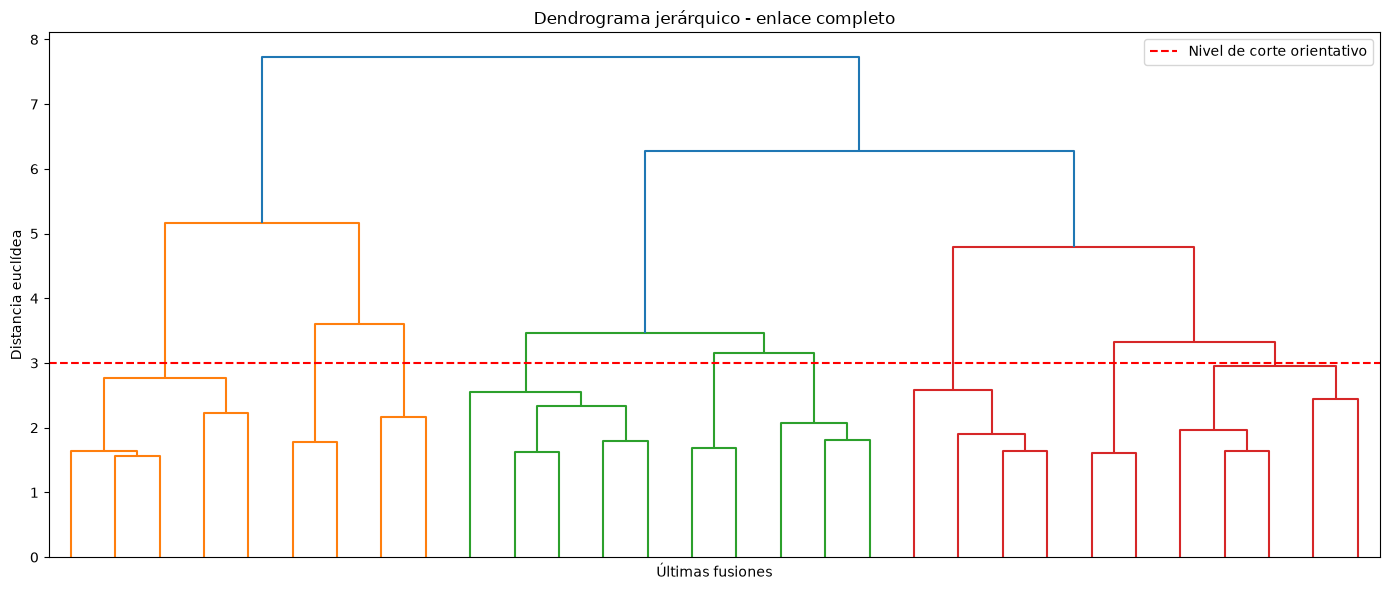

Distancias de las últimas 10 fusiones:


,Distancia
0,2.764
1,2.955
2,3.158
3,3.330
4,3.456
5,3.599
6,4.796
7,5.166
8,6.276
9,7.723


In [13]:
Z = linkage(X_scaled, method="complete", metric="euclidean")

plt.figure(figsize=(14, 6))
dendrogram(
    Z,
    truncate_mode="lastp",
    p=30,
    no_labels=True,
    color_threshold=None
)
plt.title("Dendrograma jerárquico - enlace completo")
plt.xlabel("Últimas fusiones")
plt.ylabel("Distancia euclídea")
plt.axhline(y=3.0, color="red", linestyle="--", label="Nivel de corte orientativo")
plt.legend()
plt.tight_layout()
plt.show()

print("Distancias de las últimas 10 fusiones:")
display(pd.DataFrame({"Distancia": Z[-10:, 2]}).round(3))

In [14]:
modelo_jerarquico = AgglomerativeClustering(
    n_clusters=K_SELECCIONADO,
    metric="euclidean",
    linkage="complete"
)
etiquetas_jerarquico = modelo_jerarquico.fit_predict(X_scaled)

datos_jerarquico = datos.copy()
datos_jerarquico["Cluster"] = etiquetas_jerarquico

silueta_jerarquico = silhouette_score(
    X_scaled,
    etiquetas_jerarquico,
    sample_size=min(1000, len(X_scaled)),
    random_state=RANDOM_STATE
)

print(f"Silueta del agrupamiento jerárquico: {silueta_jerarquico:.3f}")
print("Cantidad de clientes por cluster:")
display(datos_jerarquico["Cluster"].value_counts().sort_index().rename("Cantidad"))

Silueta del agrupamiento jerárquico: 0.406
Cantidad de clientes por cluster:


Cluster
0     256
1     276
2    1468
Name: Cantidad, dtype: int64

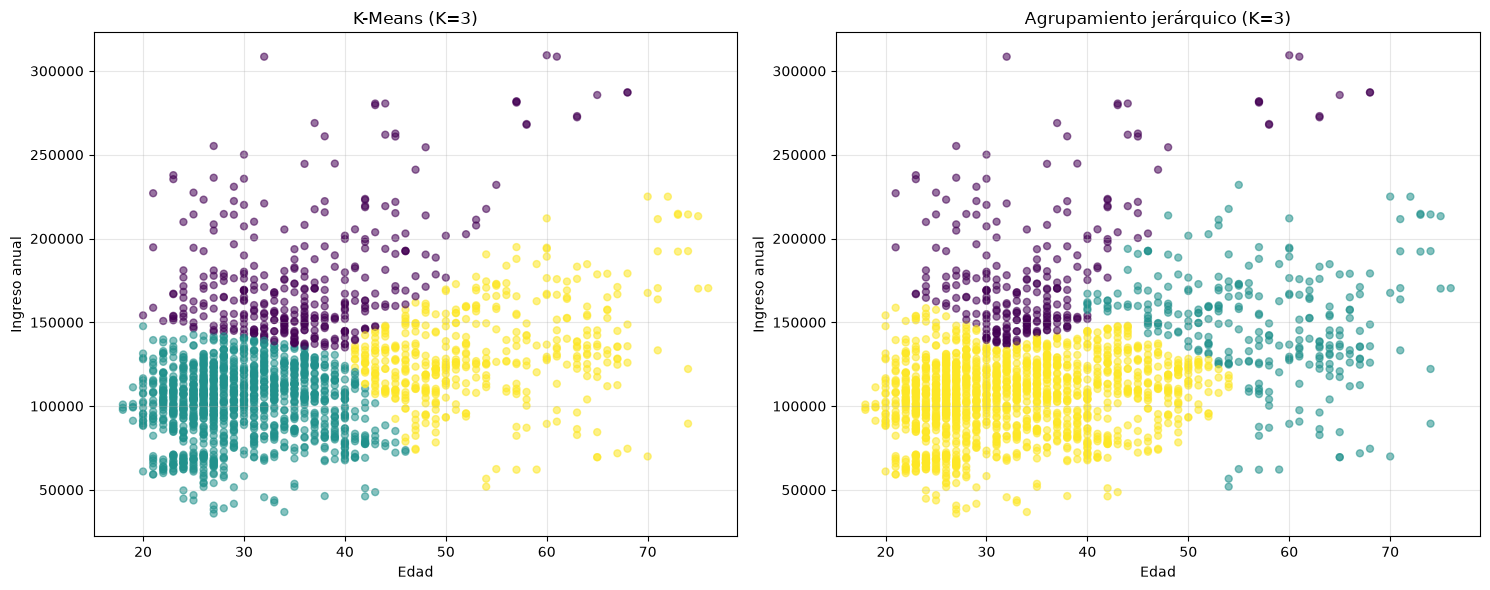

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].scatter(
    datos_segmentados["Age"],
    datos_segmentados["Income"],
    c=datos_segmentados["Cluster"],
    cmap="viridis",
    alpha=0.55,
    s=25
)
axes[0].set_title("K-Means (K=3)")
axes[0].set_xlabel("Edad")
axes[0].set_ylabel("Ingreso anual")
axes[0].grid(alpha=0.3)

axes[1].scatter(
    datos_jerarquico["Age"],
    datos_jerarquico["Income"],
    c=datos_jerarquico["Cluster"],
    cmap="viridis",
    alpha=0.55,
    s=25
)
axes[1].set_title("Agrupamiento jerárquico (K=3)")
axes[1].set_xlabel("Edad")
axes[1].set_ylabel("Ingreso anual")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Comparación e interpretación

El dendrograma muestra saltos importantes en las últimas distancias de fusión. Un corte cercano a la distancia 3 permite obtener tres grupos principales, por lo que resulta compatible con la elección de $K=3$ realizada con K-Means.

Para $K=3$, K-Means obtiene un coeficiente de silueta aproximado de $0{,}450$ y el agrupamiento jerárquico obtiene aproximadamente $0{,}406$. En este conjunto de datos, K-Means presenta una separación ligeramente mejor según este criterio.

Visualmente, K-Means forma grupos más equilibrados y con límites más graduales en el plano edad-ingreso. El método jerárquico produce un cluster mayoritario y dos grupos más pequeños, por lo que la distribución de tamaños es más desbalanceada.

Ambos métodos utilizan las mismas variables estandarizadas, pero pueden producir particiones diferentes porque K-Means optimiza la distancia a centroides, mientras que el método jerárquico construye grupos mediante fusiones sucesivas según el enlace completo.

### 8. Análisis final

A partir de todo el procedimiento, responda:

1. ¿Qué valor de $K$ considera más adecuado para K-Means? Fundamente utilizando WCSS, silueta e interpretación de los clusters.
2. ¿Qué perfiles de clientes identifica?
3. ¿Qué diferencias encuentra entre K-Means y el agrupamiento jerárquico?
4. ¿Qué limitación introduce construir los clusters únicamente con `Age` e `Income`?
5. ¿Por qué no sería correcto afirmar que los clusters encontrados son las únicas categorías posibles de clientes?

In [16]:
silueta_kmeans = resultados_kmeans.loc[
    resultados_kmeans["K"] == K_SELECCIONADO,
    "Silueta"
].iloc[0]

print(f"K seleccionado: {K_SELECCIONADO}")
print(f"Silueta de K-Means: {silueta_kmeans:.3f}")
print(f"Silueta del método jerárquico: {silueta_jerarquico:.3f}")
print("\nConclusión: K=3 ofrece el mejor equilibrio entre reducción de WCSS, silueta y capacidad de interpretación.")

K seleccionado: 3
Silueta de K-Means: 0.450
Silueta del método jerárquico: 0.406

Conclusión: K=3 ofrece el mejor equilibrio entre reducción de WCSS, silueta y capacidad de interpretación.


Respuestas

1. Elección del valor de K

   Se considera adecuado utilizar K=3. El método del codo muestra una reducción importante de la WCSS hasta aproximadamente ese valor. Además, la silueta para K=3 es la más alta entre las alternativas analizadas en el diagrama de silueta, con un valor aproximado de 0,461 en la muestra utilizada. Aunque K=2 también presenta una buena silueta, K=3 permite distinguir perfiles de clientes más específicos sin generar grupos excesivamente fragmentados.

2. Perfiles de clientes identificados

   - Un grupo joven y numeroso, con ingresos medios.
   - Un grupo con los ingresos más altos y edad intermedia.
   - Un grupo de clientes de mayor edad, con ingresos medios-altos y mayor presencia de educación universitaria.

3. Diferencias entre los métodos

   K-Means asigna cada observación al centroide más cercano y busca minimizar la WCSS. El método jerárquico aglomerativo comienza con observaciones individuales y las fusiona progresivamente según la distancia y el enlace completo. Para K=3, K-Means obtuvo una silueta aproximada de 0,450, superior al 0,406 del método jerárquico, y produjo grupos más equilibrados.

4. Limitación de utilizar solo Age e Income

   Los clusters se construyeron únicamente según edad e ingreso. Por lo tanto, dos clientes con valores similares en esas variables pueden pertenecer al mismo grupo aunque tengan diferente género, educación, ocupación, estado civil o tamaño de ciudad. Esas características sirven para interpretar los grupos, pero no influyeron en su formación.

5. Por qué no son categorías únicas


   Los clusters dependen de las variables seleccionadas, del escalado, del algoritmo, del número de grupos y de sus parámetros. Otra selección de variables o método podría producir una segmentación diferente. Por eso deben interpretarse como una herramienta útil para resumir tendencias, no como categorías naturales, definitivas o excluyentes de los clientes.